<a href="https://colab.research.google.com/github/kmillaevelyn/data-science-portfolio/blob/main/01-machine-learning/classificacao-termica-motores-pi5/pi5-classificacao-termica-motores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =====================================================================
# PROJETO INTEGRADOR 5 - Classificacao de Imagens Termicas de Motor
# Bloco 0: Setup, montagem do Drive e configuracao de caminhos
# =====================================================================

# Monta o Google Drive (rode no Colab)
from google.colab import drive
drive.mount('/content/drive')

# Bibliotecas base
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ---------------------------------------------------------------------
# AJUSTE AQUI o caminho onde voce colocou a pasta no seu Drive.
# A pasta deve conter as 4 subpastas:
#   Treino_H_M, Treino_H_F, Teste_H_M, Teste_H_F
# ---------------------------------------------------------------------
BASE_DIR = "/content/drive/MyDrive/pi5/Bases_Img_Termica_Motor"

# Verificacao rapida da estrutura
print("Conteudo de BASE_DIR:")
for nome in sorted(os.listdir(BASE_DIR)):
    caminho = os.path.join(BASE_DIR, nome)
    if os.path.isdir(caminho):
        n = len([f for f in os.listdir(caminho) if f.lower().endswith(".jpg")])
        print(f"  {nome}: {n} imagens .jpg")

# Semente global para reprodutibilidade
SEED = 42
np.random.seed(SEED)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Conteudo de BASE_DIR:
  Teste_H_F: 27 imagens .jpg
  Teste_H_M: 27 imagens .jpg
  Treino_H_F: 88 imagens .jpg
  Treino_H_M: 55 imagens .jpg


Formato de X_treino: (143, 4096) (imagens, pixels por imagem)
y [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1] (rotulos de cada imagem)
Formato de X_teste:  (54, 4096)
Distribuicao treino: [55 88] -> [normal, maxima]
Distribuicao teste:  [27 27] -> [normal, maxima]


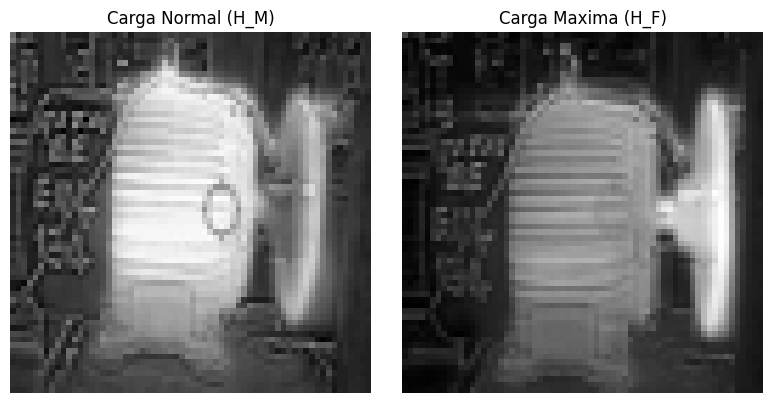

In [ ]:
# =====================================================================
# Bloco 1: Pre-processamento e vetorizacao das imagens
# Converte cada imagem em: escala de cinza -> resize -> flatten -> vetor
# =====================================================================

# Tamanho final de cada imagem (lado a lado). 64x64 = 4096 features por imagem.
IMG_SIZE = (64, 64)

# ---------------------------------------------------------------------
# MAPEAMENTO DAS CLASSES
# H_M = motor em CARGA NORMAL    -> classe 0
# H_F = motor em CARGA MAXIMA    -> classe 1  (Full / sobrecarga)
# ---------------------------------------------------------------------
MAPA_CLASSES = {"H_M": 0, "H_F": 1}
NOMES_CLASSES = {0: "Carga Normal (H_M)", 1: "Carga Maxima (H_F)"}

def carregar_conjunto(prefixo):
    """
    Carrega um conjunto (Treino ou Teste) a partir das subpastas <prefixo>_H_M
    e <prefixo>_H_F. Retorna X (matriz de vetores) e y (rotulos).
    """
    X, y = [], []
    for sufixo, rotulo in MAPA_CLASSES.items():
        pasta = os.path.join(BASE_DIR, f"{prefixo}_{sufixo}")
        arquivos = sorted(f for f in os.listdir(pasta) if f.lower().endswith(".jpg"))
        for nome_arq in arquivos:
            caminho = os.path.join(pasta, nome_arq)

            # 1) abre a imagem  2) converte para tons de cinza ('L')
            # 3) redimensiona para o tamanho fixo
            img = Image.open(caminho).convert("L").resize(IMG_SIZE)

            # 4) matriz -> vetor unidimensional (flatten)
            vetor = np.asarray(img, dtype=np.float32).flatten()
            X.append(vetor)
            y.append(rotulo)

    return np.array(X), np.array(y)

# Constroi treino e teste usando a divisao que ja vem pronta na base
X_treino, y_treino = carregar_conjunto("Treino")
X_teste,  y_teste  = carregar_conjunto("Teste")

print("Formato de X_treino:", X_treino.shape, "(imagens, pixels por imagem)")
print("Formato de X_teste: ", X_teste.shape)
print("Distribuicao treino:", np.bincount(y_treino), "-> [normal, maxima]")
print("Distribuicao teste: ", np.bincount(y_teste),  "-> [normal, maxima]")

# Visualizacao de exemplo: uma imagem de cada classe ja pre-processada
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, classe in zip(axes, [0, 1]):
    idx = np.where(y_treino == classe)[0][0]
    ax.imshow(X_treino[idx].reshape(IMG_SIZE), cmap="gray")
    ax.set_title(NOMES_CLASSES[classe])
    ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# =====================================================================
# Bloco 2: Treinamento e Ajuste de Hiperparâmetros
# Ajuste dos 5 algoritmos via GridSearchCV utilizando o conjunto de treino
# =====================================================================

from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

print("Iniciando a otimização dos modelos individuais...\n")

# 1. KNN
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid={'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']},
    cv=3, scoring='accuracy', n_jobs=-1
)
knn_grid.fit(X_treino, y_treino)
best_knn = knn_grid.best_estimator_
print(f"KNN otimizado: {knn_grid.best_params_} (Acurácia Val: {knn_grid.best_score_:.4f})")

# 2. Árvore de Decisão
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=SEED),
    param_grid={'max_depth': [None, 5, 10, 15], 'min_samples_split': [2, 5, 10]},
    cv=3, scoring='accuracy', n_jobs=-1
)
dt_grid.fit(X_treino, y_treino)
best_dt = dt_grid.best_estimator_
print(f"Árvore de Decisão otimizada: {dt_grid.best_params_} (Acurácia Val: {dt_grid.best_score_:.4f})")

# 3. Random Forest
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=SEED),
    param_grid={'n_estimators': [50, 100, 200], 'max_depth': [None, 5, 10]},
    cv=3, scoring='accuracy', n_jobs=-1, bootstrap = True, max_features = 'sqrt'
)
rf_grid.fit(X_treino, y_treino)
best_rf = rf_grid.best_estimator_
print(f"Random Forest otimizado: {rf_grid.best_params_} (Acurácia Val: {rf_grid.best_score_:.4f})")

# 4. SVM com Kernel Linear
svm_linear_grid = GridSearchCV(
    SVC(kernel='linear', random_state=SEED),
    param_grid={'C': [0.01, 0.1, 1, 10]},
    cv=3, scoring='accuracy', n_jobs=-1
)
svm_linear_grid.fit(X_treino, y_treino)
best_svm_linear = svm_linear_grid.best_estimator_
print(f"SVM Linear otimizado: {svm_linear_grid.best_params_} (Acurácia Val: {svm_linear_grid.best_score_:.4f})")

# 5. SVM com Kernel Polinomial de 2° Grau
svm_poly_grid = GridSearchCV(
    SVC(kernel='poly', degree=2, random_state=SEED),
    param_grid={'C': [0.01, 0.1, 1, 10], 'gamma': ['scale', 'auto']},
    cv=3, scoring='accuracy', n_jobs=-1
)
svm_poly_grid.fit(X_treino, y_treino)
best_svm_poly = svm_poly_grid.best_estimator_
print(f"SVM Poly (2º Grau) otimizado: {svm_poly_grid.best_params_} (Acurácia Val: {svm_poly_grid.best_score_:.4f})")

print("\nTodos os modelos individuais foram ajustados com sucesso!")

Iniciando a otimização dos modelos individuais...



NameError: name 'X_treino' is not defined


=== RELATÓRIOS DE CLASSIFICAÇÃO NO CONJUNTO DE TESTE ===

--- KNN ---
                    precision    recall  f1-score   support

Carga Normal (H_M)       0.83      0.70      0.76        27
Carga Maxima (H_F)       0.74      0.85      0.79        27

          accuracy                           0.78        54
         macro avg       0.78      0.78      0.78        54
      weighted avg       0.78      0.78      0.78        54

--- Árvore de Decisão ---
                    precision    recall  f1-score   support

Carga Normal (H_M)       0.85      0.81      0.83        27
Carga Maxima (H_F)       0.82      0.85      0.84        27

          accuracy                           0.83        54
         macro avg       0.83      0.83      0.83        54
      weighted avg       0.83      0.83      0.83        54

--- Random Forest ---
                    precision    recall  f1-score   support

Carga Normal (H_M)       0.86      0.67      0.75        27
Carga Maxima (H_F)       0.73     

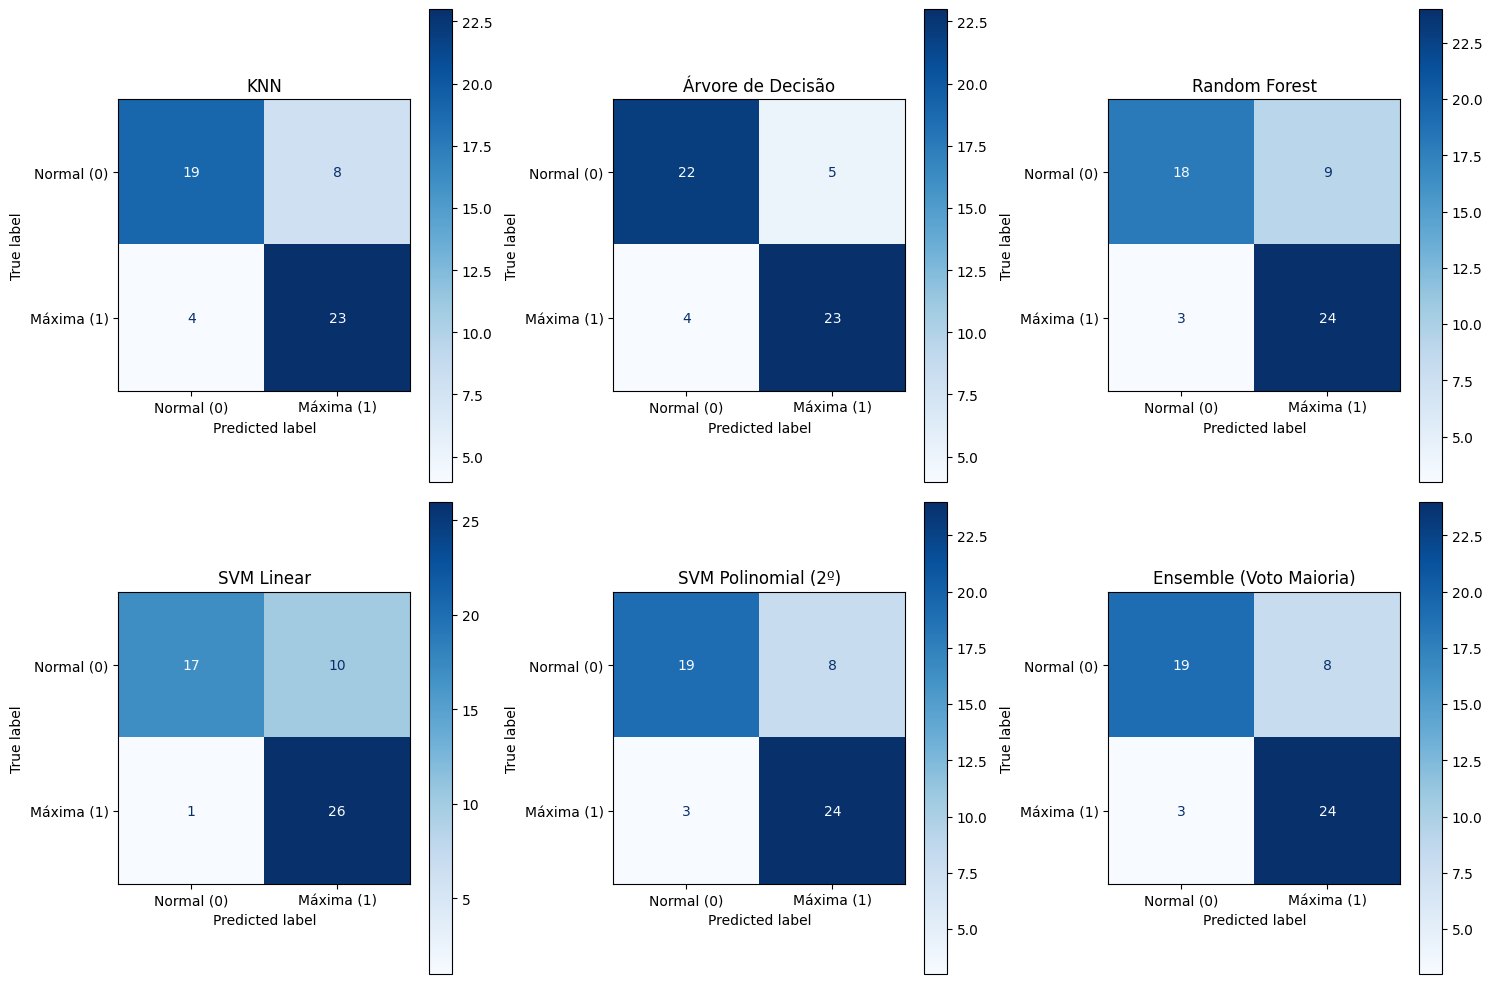

In [ ]:
# =====================================================================
# Bloco 3: Ensemble (Voto da Maioria) e Avaliação no Conjunto de Teste
# Combinação dos classificadores e plotagem das matrizes de confusão
# =====================================================================

from sklearn.ensemble import VotingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Criando o Ensemble com voto da maioria (Hard Voting)
ensemble = VotingClassifier(
    estimators=[
        ('knn', best_knn),
        ('dt', best_dt),
        ('rf', best_rf),
        ('svm_linear', best_svm_linear),
        ('svm_poly', best_svm_poly)
    ],
    voting='hard'
)

# Treina o agregador no conjunto de treino completo
ensemble.fit(X_treino, y_treino)

# Dicionário com todos os modelos candidatos à avaliação
modelos_finais = {
    "KNN": best_knn,
    "Árvore de Decisão": best_dt,
    "Random Forest": best_rf,
    "SVM Linear": best_svm_linear,
    "SVM Polinomial (2º)": best_svm_poly,
    "Ensemble (Voto Maioria)": ensemble
}

# Configuração gráfica para exibir 2 linhas e 3 colunas de matrizes de confusão
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

print("\n=== RELATÓRIOS DE CLASSIFICAÇÃO NO CONJUNTO DE TESTE ===\n")

for i, (nome, modelo) in enumerate(modelos_finais.items()):
    # Predição no conjunto de teste
    y_pred = modelo.predict(X_teste)

    # Impressão textual das métricas para análise detalhada
    print(f"--- {nome} ---")
    print(classification_report(y_teste, y_pred, target_names=[NOMES_CLASSES[0], NOMES_CLASSES[1]]))

    # Cálculo e exibição gráfica da matriz de confusão
    cm = confusion_matrix(y_teste, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal (0)", "Máxima (1)"])
    disp.plot(ax=axes[i], cmap='Blues', values_format='d')
    axes[i].set_title(nome)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2317/1681695780.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='Acuracia', data=df_comparacao_grayscale, ax=ax, palette='Blues', order=ordem_modelos)


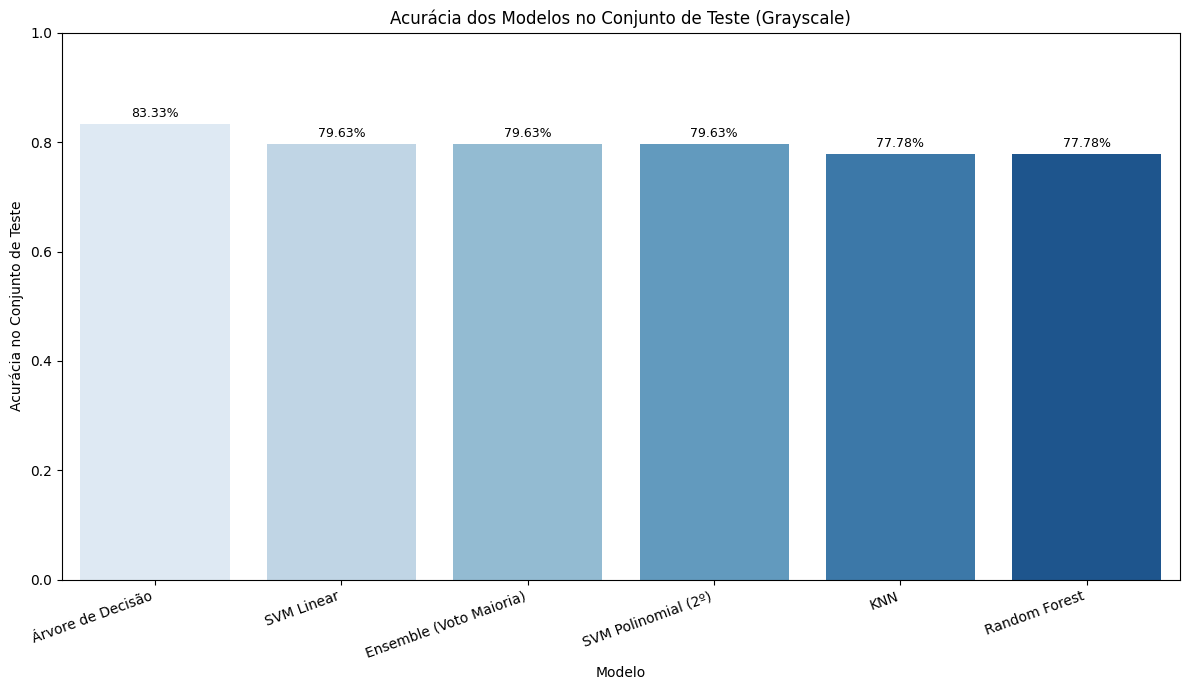


Ranking final de acuracia (teste, apenas Grayscale):
  Árvore de Decisão: 83.33%
  SVM Linear: 79.63%
  Ensemble (Voto Maioria): 79.63%
  SVM Polinomial (2º): 79.63%
  KNN: 77.78%
  Random Forest: 77.78%


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

# Recalcula as acurácias para grayscale (certificar que estamos usando os modelos corretos)
# Os modelos_finais já foram definidos no Bloco 3 e utilizam X_teste e y_teste (grayscale)
acuracias_grayscale_calculated = {
    nome: accuracy_score(y_teste, modelo.predict(X_teste))
    for nome, modelo in modelos_finais.items()
}

# Preparar dados para o DataFrame (apenas grayscale)
dados_plot_grayscale = []

for nome_modelo_gray in acuracias_grayscale_calculated.keys():
    dados_plot_grayscale.append({
        'Modelo': nome_modelo_gray,
        'Acuracia': acuracias_grayscale_calculated[nome_modelo_gray]
    })

df_comparacao_grayscale = pd.DataFrame(dados_plot_grayscale)

# Ordenar modelos por acuracia Grayscale decrescente
ordem_modelos = df_comparacao_grayscale.sort_values(by='Acuracia', ascending=False)['Modelo'].tolist()

# Bloco 4: Comparacao Visual de Acuracia (apenas Grayscale)
fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(x='Modelo', y='Acuracia', data=df_comparacao_grayscale, ax=ax, palette='Blues', order=ordem_modelos)

ax.set_ylim(0, 1.0)
ax.set_ylabel('Acurácia no Conjunto de Teste')
ax.set_title('Acurácia dos Modelos no Conjunto de Teste (Grayscale)')

# Adicionar valores nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='{:.2%}', fontsize=9, padding=3)

plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

print("\nRanking final de acuracia (teste, apenas Grayscale):")
for nome_modelo_gray in ordem_modelos:
    acc_gray = acuracias_grayscale_calculated.get(nome_modelo_gray, None)
    if acc_gray is not None: print(f"  {nome_modelo_gray}: {acc_gray:.2%}")